In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('glass.csv')
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(999, 10)

In [4]:
df.size

9990

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


In [6]:
df.isnull().sum()

RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64

In [7]:
for col in df.select_dtypes(include=['int','float']).columns:
    print(col,end="','")

RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','Type','

In [8]:
#there are so many null values which may make model less accurate
#The result will be affected.so,we used imputation to fill with median
#Because even if there would be outliers median values will be consistent
from sklearn.impute import SimpleImputer
cols=['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','Type']
imputer=SimpleImputer(strategy='median')
df[cols]=imputer.fit_transform(df[cols])

In [9]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(785)

In [11]:
#Duplication will affect the data and values will not be accurate
#So,we will drop them for better model training.
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

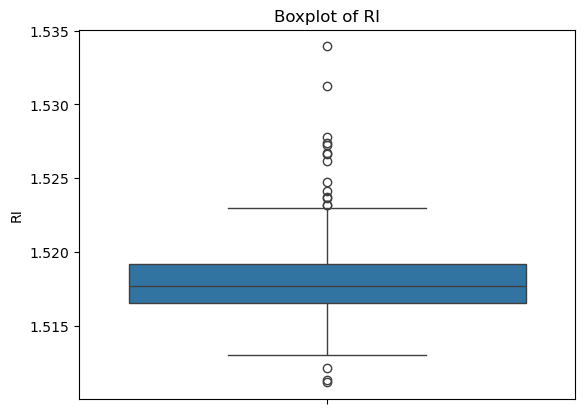

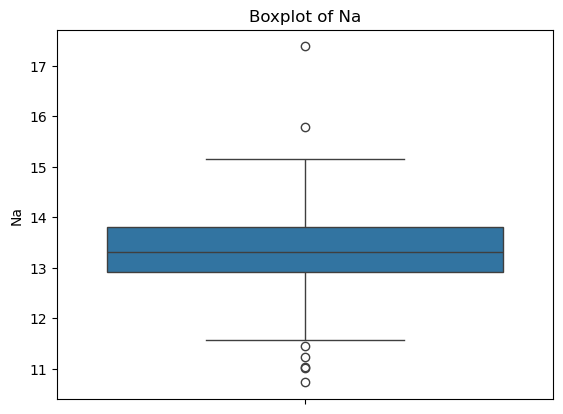

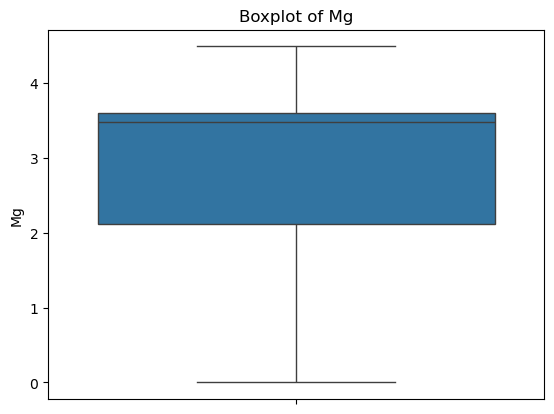

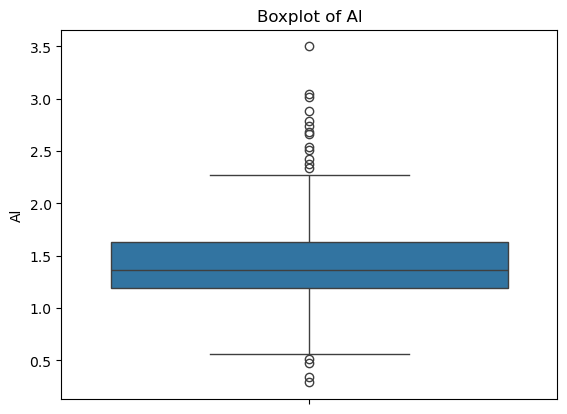

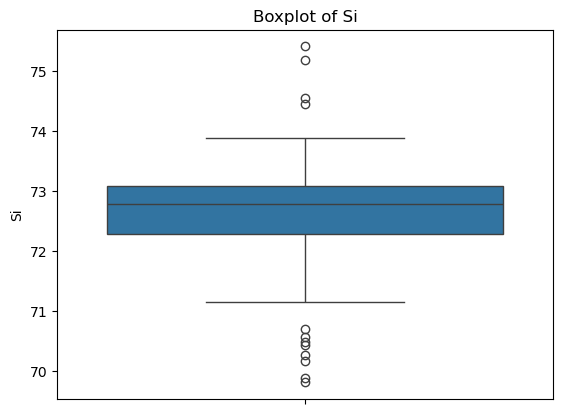

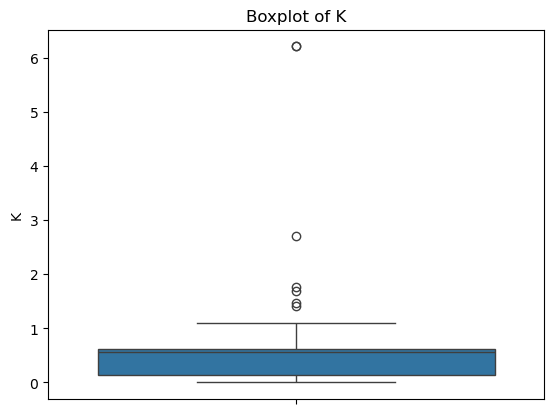

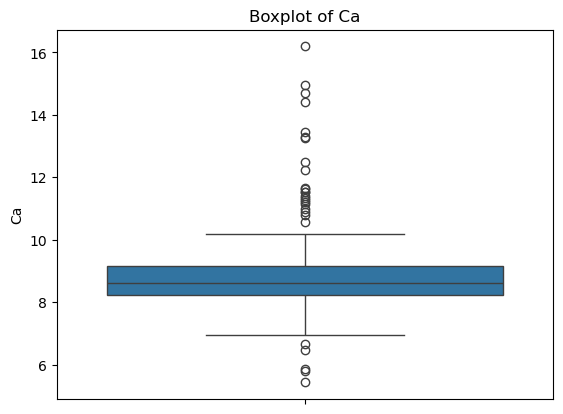

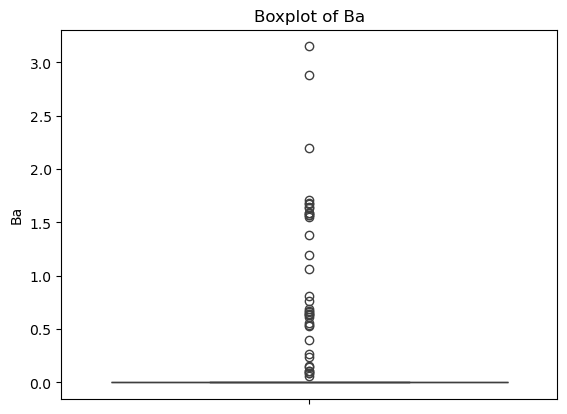

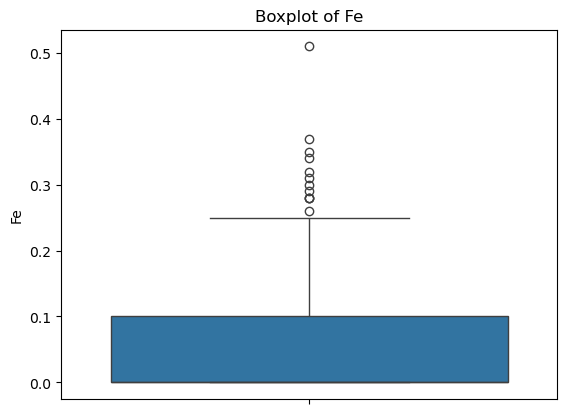

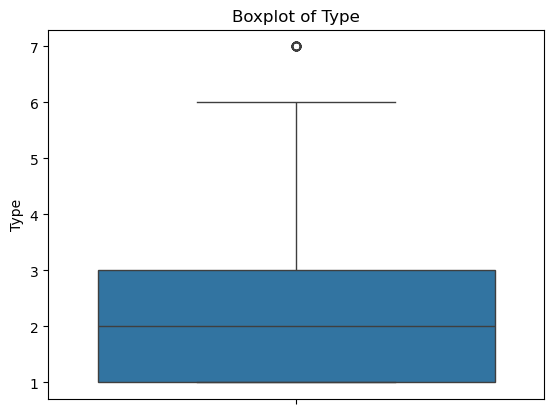

In [13]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

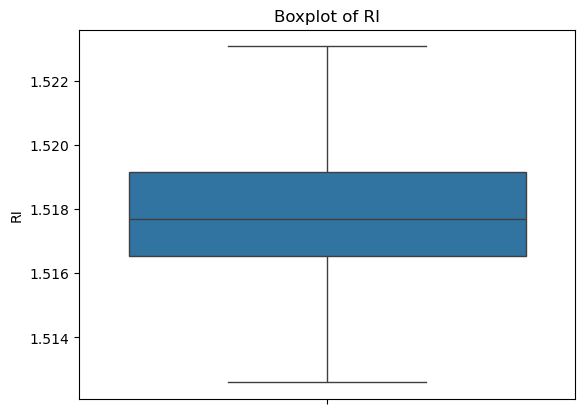

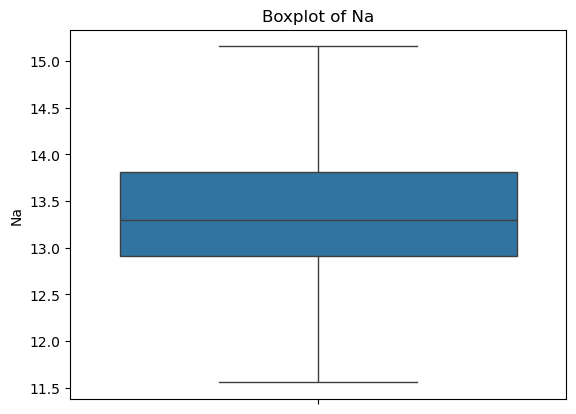

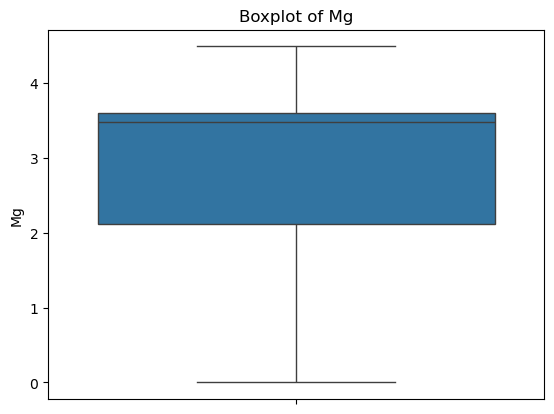

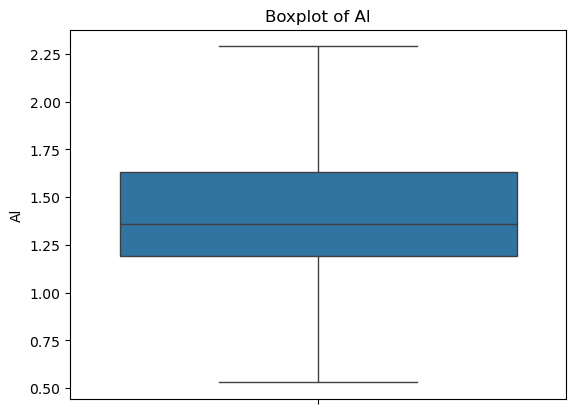

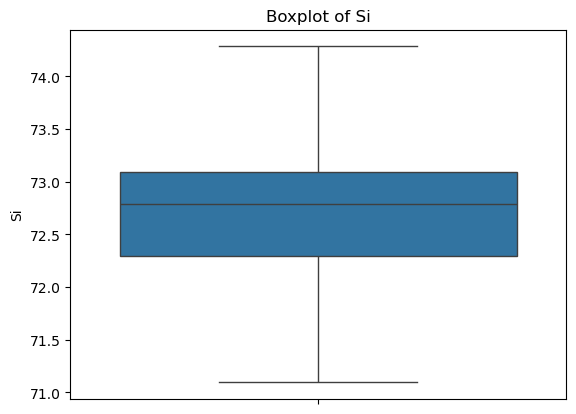

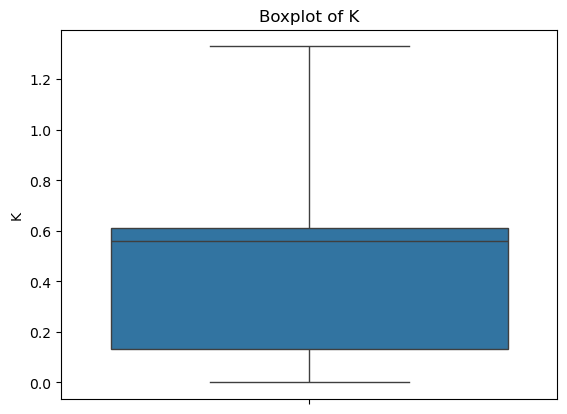

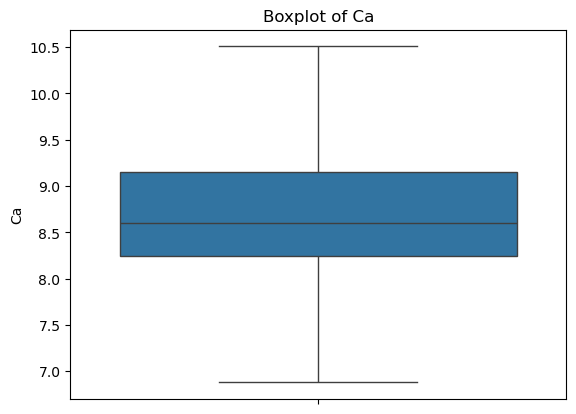

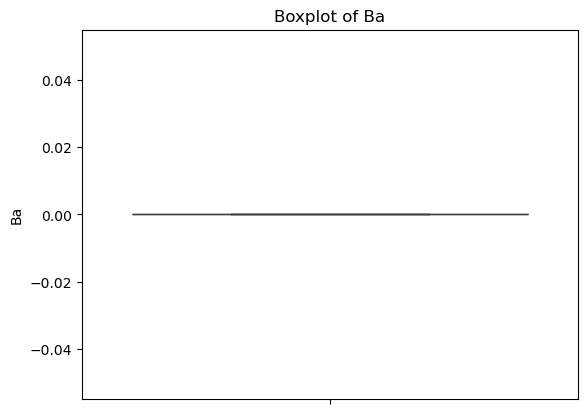

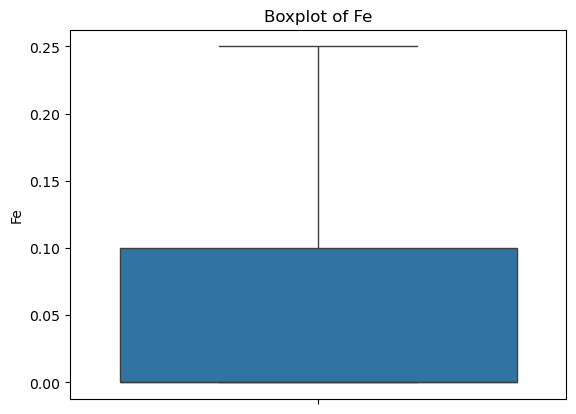

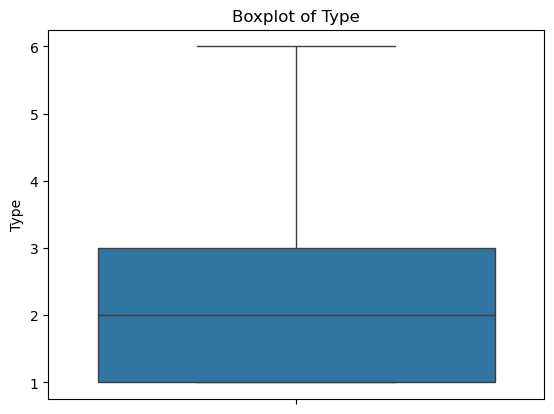

In [15]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

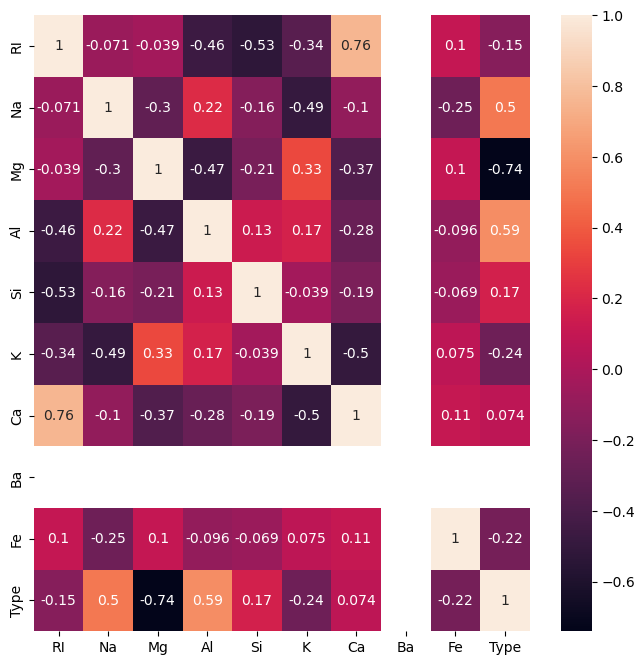

In [16]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 214
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 18.4 KB


In [18]:
#There are no categorical columns to perform encoding techniques.

In [19]:
x=df.drop(columns=['Type'])
y=df['Type']

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
for col in df.select_dtypes(include=['int','float']).columns:
    df[col]=sc.fit_transform(df[[col]])
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.222857,0.324325,1.256675,-0.774974,-1.373613,-1.257808,-0.042919,0.0,-0.619091,-0.898848
1,-0.226570,0.663767,0.637745,-0.154370,0.085440,0.123315,-1.118495,0.0,-0.619091,-0.898848
2,-0.836182,0.174971,0.602974,0.275279,0.484760,-0.172640,-1.176950,0.0,-0.619091,-0.898848
3,-0.205255,-0.259514,0.700333,-0.321456,-0.098861,0.419269,-0.662544,0.0,-0.619091,-0.898848
4,-0.307567,-0.178048,0.651654,-0.440803,0.622986,0.353502,-0.837910,0.0,-0.619091,-0.898848


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                  max_samples=0.6, max_features=0.7,max_depth=10)
rf_model.fit(x_train, y_train)
y_pred_train_rf = rf_model.predict(x_train)
y_pred_test_rf = rf_model.predict(x_test)
training_accuracy_rf = accuracy_score(y_train, y_pred_train_rf)
test_accuracy_rf = accuracy_score(y_test, y_pred_test_rf)
print("Random Forest - Training Accuracy:", np.round(training_accuracy_rf,2))
print("Random Forest - Test Accuracy:", np.round(test_accuracy_rf,2))

Random Forest - Training Accuracy: 0.96
Random Forest - Test Accuracy: 0.63


In [24]:
from sklearn.metrics import * 
test_precision_score = precision_score(y_test, y_pred_test_rf,average='weighted')
test_recall_score = recall_score(y_test, y_pred_test_rf,average='weighted')
test_f1_score = f1_score(y_test, y_pred_test_rf,average='weighted')
print("Random Forest - Precision Score:", np.round(test_precision_score,2))
print("Random Forest - Recall Score:", np.round(test_recall_score,2))
print("Random Forest - F1 Score:", np.round(test_recall_score,2))

Random Forest - Precision Score: 0.65
Random Forest - Recall Score: 0.63
Random Forest - F1 Score: 0.63


In [25]:
# BAGGING CLASSIFIER
from sklearn.ensemble import BaggingClassifier
bagging_model = BaggingClassifier(estimator=RandomForestClassifier(criterion='gini'),
                                  n_estimators=100, random_state=42,
                                  max_samples=0.6,max_features=0.7,bootstrap_features=True)
bagging_model.fit(x_train, y_train)
y_pred_train_bagging = bagging_model.predict(x_train)
y_pred_test_bagging = bagging_model.predict(x_test)
training_accuracy_bagging = accuracy_score(y_train, y_pred_train_bagging)
test_accuracy_bagging = accuracy_score(y_test, y_pred_test_bagging)
print("Bagging - Training Accuracy:", np.round(training_accuracy_bagging,2))
print("Bagging - Test Accuracy:", np.round(test_accuracy_bagging,2))

Bagging - Training Accuracy: 0.96
Bagging - Test Accuracy: 0.74


In [26]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
gbc.fit(x_train,y_train)
pred_train=gbc.predict(x_train)
pred_test=gbc.predict(x_test)
from sklearn.metrics import *
print("Train Accuracy:",accuracy_score(y_train,pred_train))
print("Test Accuracy:",accuracy_score(y_test,pred_test))

Train Accuracy: 1.0
Test Accuracy: 0.6511627906976745


Bagging and Boosting:
Bagging (Bootstrap Aggregating):
1.Parallel method: Multiple models are trained independently and at the same time using different random samples of the training data.
2.Reduces variance: The predictions of all models are combined (voting for classification, averaging for regression), which reduces overfitting.
3.Example: Random Forest is a popular bagging-based algorithm.
Boosting:
1.Sequential method: Models are trained one after another, where each new model focuses more on the errors made by previous models.
2.Reduces bias: Combining weak learners sequentially creates a strong learner and improves prediction accuracy.
3.Examples: AdaBoost, Gradient Boosting, and XGBoost.

Handling Imbalanced Data:
1.Oversampling: Increase the number of samples in the minority class,eg:using SMOTE.
2.Undersampling: Reduce samples from the majority class to balance the dataset.
3.Class Weights:Give higher importance/weight to the minority class during model training.
4.Use Suitable Metrics:Evaluate using Precision, Recall, F1-score, and ROC-AUC instead of accuracy alone.
5.Ensemble Methods:Use algorithms such as Random Forest or Boosting that can handle class imbalance effectively.